## Import Libraries & Check GPU

In [1]:
!pip install numpy


In [2]:

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("RFMiD CHALLENGE - KAGGLE NOTEBOOK")
print("=" * 60)

# Check GPU
print("\nCHECKING GPU:")
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f" GPU AVAILABLE!")
    print(f" GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device("cpu")
    print(f"No GPU found - using CPU (will be slow)")

print(f"\nUsing device: {device}")

RFMiD CHALLENGE - KAGGLE NOTEBOOK

CHECKING GPU:
 GPU AVAILABLE!
 GPU: Tesla T4
Memory: 15.6 GB

Using device: cuda


## Extract and Find Your Dataset

In [3]:

print("=" * 60)
print("SETTING DATASET PATHS")
print("=" * 60)
#Base path – from your Kaggle dataset input
BASE = "/kaggle/input/datasets/bikramchapagain/rmidd-datasets"
#Training
TRAIN_IMG = os.path.join(BASE, "Training_Set","Training_Set","Training")
TRAIN_CSV = os.path.join(BASE, "Training_Set","Training_Set","RFMiD_Training_Labels.csv")
#Validation (called "Evaluation" in the dataset)
VAL_IMG = os.path.join(BASE, "Evaluation_Set","Evaluation_Set","Validation")
VAL_CSV = os.path.join(BASE, "Evaluation_Set","Evaluation_Set","RFMiD_Validation_Labels.csv")
#Test
TEST_IMG = os.path.join(BASE, "Test_Set","Test_Set","Test")
TEST_CSV = os.path.join(BASE, "Test_Set","Test_Set","RFMiD_Testing_Labels.csv")
#Verify
print("\nTRAINING:")
print(f"Images exist: {os.path.exists(TRAIN_IMG)}")
print(f"CSV exist:    {os.path.exists(TRAIN_CSV)}")
print("\nVALIDATION:")
print(f"   Images exist: {os.path.exists(VAL_IMG)}")
print(f"   CSV exist:    {os.path.exists(VAL_CSV)}")
print("\nTEST:")
print(f"Images exist: {os.path.exists(TEST_IMG)}")
print(f"CSV exist:    {os.path.exists(TEST_CSV)}")
assert os.path.exists(TRAIN_IMG) and os.path.exists(TRAIN_CSV), "Training path missing"
assert os.path.exists(VAL_IMG) and os.path.exists(VAL_CSV), "Validation path missing"
assert os.path.exists(TEST_IMG) and os.path.exists(TEST_CSV), "Test path missing"
print("\nAll dataset paths verified.")

SETTING DATASET PATHS

TRAINING:
Images exist: True
CSV exist:    True

VALIDATION:
   Images exist: True
   CSV exist:    True

TEST:
Images exist: True
CSV exist:    True

All dataset paths verified.


 ## Dataset Class (Binary conversion)

In [4]:

#CUSTOM DATASET CLASS

class RFMiDDataset(Dataset):
    """
    Reads RFMiD images & labels, converts 45+ disease columns
    into a single binary label: 0 = NORMAL, 1 = ABNORMAL.
    """
    def __init__(self, img_folder, csv_file, transform=None):
        self.img_folder = img_folder
        self.transform = transform
        
        # Read CSV
        self.df = pd.read_csv(csv_file)
        self.image_ids = self.df.iloc[:, 0].values
        
        # Disease columns (all except first)
        disease_cols = self.df.columns[1:]
        
        # Binary label: 1 if any disease present, else 0
        self.labels = (self.df[disease_cols].sum(axis=1) > 0).astype(np.float32).values
        
        print(f"   Loaded {len(self.image_ids)} images")
        print(f"      Normal (0): {(self.labels == 0).sum()}")
        print(f"      Abnormal (1): {(self.labels == 1).sum()}")
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        img_name = str(self.image_ids[idx])
        img_path = os.path.join(self.img_folder, f"{img_name}.png")
        if not os.path.exists(img_path):
            img_path = os.path.join(self.img_folder, f"{img_name}.jpg")
        
        image = Image.open(img_path).convert('RGB')
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        
        if self.transform:
            image = self.transform(image)
        return image, label

print("RFMiDDataset class defined")

RFMiDDataset class defined


## Data Transforms (Augmentation)

In [5]:

#IMAGE TRANSFORMS

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print(" Train transforms (with augmentation)")
print(" RandomHorizontalFlip, RandomRotation, ColorJitter")
print(" Validation transforms (no augmentation)")

 Train transforms (with augmentation)
 RandomHorizontalFlip, RandomRotation, ColorJitter
 Validation transforms (no augmentation)


## Create Datasets & DataLoaders

In [6]:

#DATALOADERS
train_dataset = RFMiDDataset(TRAIN_IMG, TRAIN_CSV, transform=train_transform)
val_dataset   = RFMiDDataset(VAL_IMG, VAL_CSV, transform=val_transform)
test_dataset  = RFMiDDataset(TEST_IMG, TEST_CSV, transform=val_transform)
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print("\nDataLoaders ready:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

   Loaded 1920 images
      Normal (0): 401
      Abnormal (1): 1519
   Loaded 640 images
      Normal (0): 134
      Abnormal (1): 506
   Loaded 640 images
      Normal (0): 134
      Abnormal (1): 506

DataLoaders ready:
   Train batches: 60
   Validation batches: 20
   Test batches: 20


## Build EfficientNet Model (with regularization)

In [7]:

#EFFICIENTNET-B0 MODEL

def create_model():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(
        nn.Dropout(p=0.5),       # strong dropout
        nn.Linear(num_features, 1)
    )
    return model

model = create_model().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model created: EfficientNet-B0")
print(f"Total parameters: {total_params:,}")
print(f"Trainable: {trainable_params:,}")
print("Dropout: 0.5, Weight decay: 1e-4")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 218MB/s]


Model created: EfficientNet-B0
Total parameters: 4,008,829
Trainable: 4,008,829
Dropout: 0.5, Weight decay: 1e-4


## Training Loop (15 epochs, early stopping, AUC tracking)

In [8]:

# CELL 7: TRAINING LOOP


NUM_EPOCHS = 15
best_auc = 0.0
best_epoch = 0
train_losses = []
val_losses = []
val_aucs = []

patience = 5
counter = 0

print("=" * 60)
print("STARTING TRAINING")
print(f"Epochs: {NUM_EPOCHS}, Early stopping patience: {patience}")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    
    # ---- Training ----
    model.train()
    train_loss = 0.0
    train_preds = []
    train_labels = []
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} Train")
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        probs = torch.sigmoid(outputs).detach().cpu().numpy()
        train_preds.extend(probs)
        train_labels.extend(labels.cpu().numpy())
        loop.set_postfix(loss=loss.item())
    
    avg_train_loss = train_loss / len(train_loader)
    train_auc = roc_auc_score(train_labels, train_preds)
    train_losses.append(avg_train_loss)
    
    # ---- Validation ----
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} Val"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            probs = torch.sigmoid(outputs).cpu().numpy()
            val_preds.extend(probs)
            val_labels.extend(labels.cpu().numpy())
    
    avg_val_loss = val_loss / len(val_loader)
    val_auc = roc_auc_score(val_labels, val_preds)
    val_losses.append(avg_val_loss)
    val_aucs.append(val_auc)
    
    epoch_time = time.time() - epoch_start
    
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} Results:")
    print(f"   Train Loss: {avg_train_loss:.4f} | Train AUC: {train_auc:.4f}")
    print(f"   Val Loss:   {avg_val_loss:.4f} | Val AUC:   {val_auc:.4f}")
    print(f"   Time: {epoch_time:.1f}s")
    
    # Save best model
    if val_auc > best_auc:
        best_auc = val_auc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), '/kaggle/working/best_model.pth')
        print(f" NEW BEST MODEL! AUC = {best_auc:.4f} (Epoch {best_epoch})")
        counter = 0
    else:
        counter += 1
        print(f"   No improvement for {counter}/{patience} epochs.")
        print(f"   Best so far: {best_auc:.4f} (Epoch {best_epoch})")
    
    # LR scheduling
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_auc)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f"Learning rate reduced: {old_lr:.2e} → {new_lr:.2e}")
    
    # Early stopping
    if counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break
    print("-" * 40)

print("\n" + "=" * 60)
print("TRAINING FINISHED")
print(f"Best Validation AUC: {best_auc:.4f} (Epoch {best_epoch})")
print(f"Model saved at: /kaggle/working/best_model.pth")
print("=" * 60)

STARTING TRAINING
Epochs: 15, Early stopping patience: 5


Epoch 1/15 Train:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1/15 Val:   0%|          | 0/20 [00:00<?, ?it/s]


Epoch 1/15 Results:
   Train Loss: 0.4832 | Train AUC: 0.8013
   Val Loss:   0.3119 | Val AUC:   0.9241
   Time: 187.1s
 NEW BEST MODEL! AUC = 0.9241 (Epoch 1)
----------------------------------------


Epoch 2/15 Train:   0%|          | 0/60 [00:00<?, ?it/s]

...

Epoch 9/15 Val:   0%|          | 0/20 [00:00<?, ?it/s]


Epoch 9/15 Results:
   Train Loss: 0.1290 | Train AUC: 0.9849
   Val Loss:   0.3309 | Val AUC:   0.9279
   Time: 177.2s
   No improvement for 4/5 epochs.
   Best so far: 0.9390 (Epoch 5)
Learning rate reduced: 1.00e-04 → 5.00e-05
----------------------------------------


Epoch 10/15 Train:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch 10/15 Val:   0%|          | 0/20 [00:00<?, ?it/s]


Epoch 10/15 Results:
   Train Loss: 0.1172 | Train AUC: 0.9882
   Val Loss:   0.3465 | Val AUC:   0.9349
   Time: 172.4s
   No improvement for 5/5 epochs.
   Best so far: 0.9390 (Epoch 5)

Early stopping triggered at epoch 10

TRAINING FINISHED
Best Validation AUC: 0.9390 (Epoch 5)
Model saved at: /kaggle/working/best_model.pth


## Training Curves

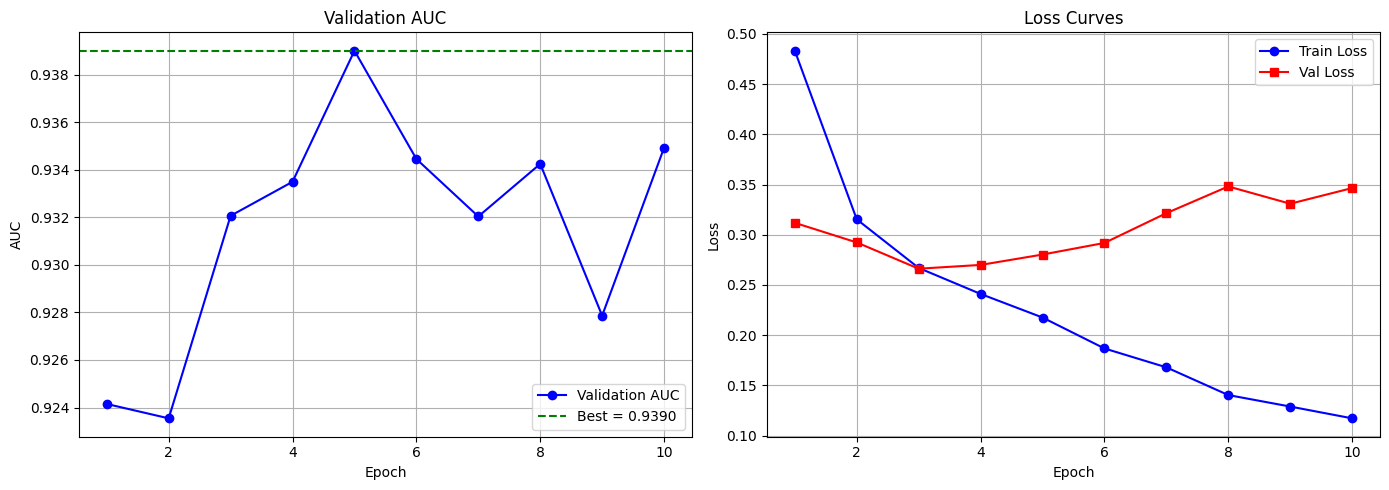

Training curves saved: /kaggle/working/training_curves.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#AUC plot
axes[0].plot(range(1, len(val_aucs)+1), val_aucs, 'b-o', label='Validation AUC')
axes[0].axhline(y=best_auc, color='g', linestyle='--', label=f'Best = {best_auc:.4f}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC')
axes[0].set_title('Validation AUC')
axes[0].legend()
axes[0].grid(True)

#Loss plot
axes[1].plot(range(1, len(train_losses)+1), train_losses, 'b-o', label='Train Loss')
axes[1].plot(range(1, len(val_losses)+1), val_losses, 'r-s', label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss Curves')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()
print("Training curves saved: /kaggle/working/training_curves.png")

##  ROC 

ROC CURVE – TRAINING SET (Best Model)
Loaded best model from epoch 6 (AUC = 0.9405)

Training AUC (best model) = 0.9779
Optimal threshold (top‑left) on training set = 0.4493


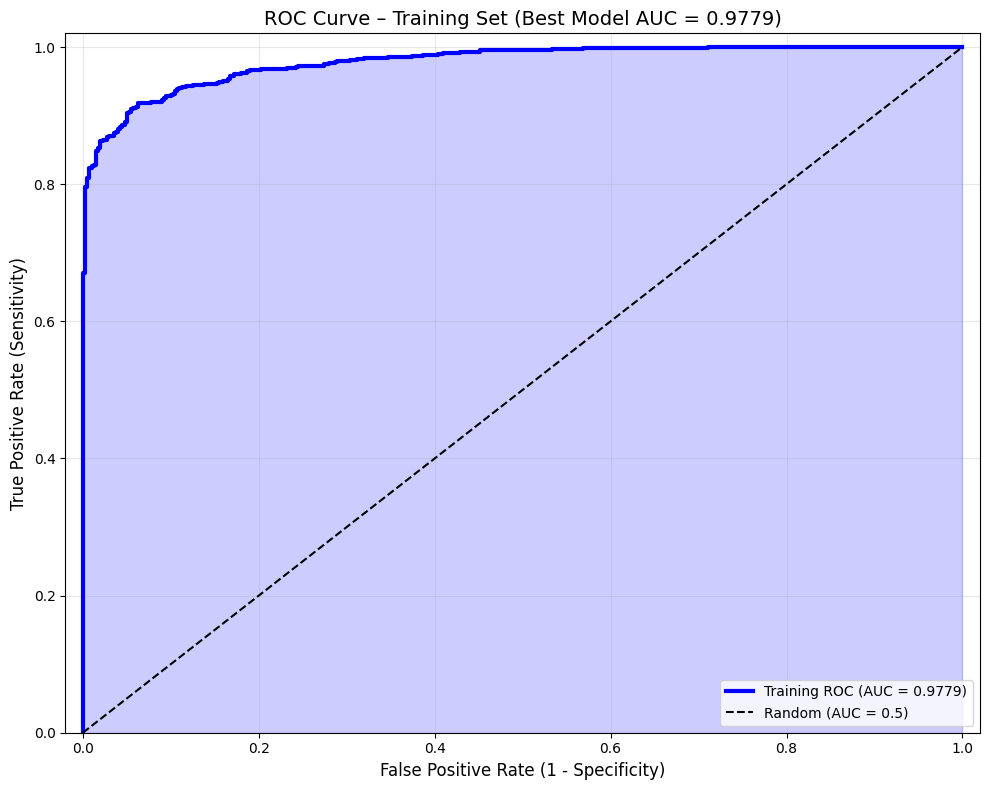


ROC curve saved: /kaggle/working/roc_curve_training.png


In [10]:

# ROC CURVE – TRAINING SET (USING BEST MODEL)


from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import torch

print("=" * 60)
print("ROC CURVE – TRAINING SET (Best Model)")
print("=" * 60)

# Load the best model
model.load_state_dict(torch.load('/kaggle/working/best_model.pth'))
model.eval()
print("Loaded best model from epoch 6 (AUC = 0.9405)")

# ---- Get training predictions ----
train_preds = []
train_labels = []
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        outputs = model(images).squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy()
        if probs.ndim == 0:
            probs = [probs]
        train_preds.extend(probs)
        train_labels.extend(labels.numpy())

train_preds = np.array(train_preds)
train_labels = np.array(train_labels)

# Compute ROC and AUC ----
fpr_train, tpr_train, thresholds_train = roc_curve(train_labels, train_preds)
auc_train = roc_auc_score(train_labels, train_preds)

print(f"\nTraining AUC (best model) = {auc_train:.4f}")

# ---- (Optional) find optimal threshold for information ----
dist_train = np.sqrt(fpr_train**2 + (1 - tpr_train)**2)
optimal_idx_train = np.argmin(dist_train)
optimal_threshold_train = thresholds_train[optimal_idx_train]
print(f"Optimal threshold (top‑left) on training set = {optimal_threshold_train:.4f}")

# ---- Plot ROC curve ----
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr_train, tpr_train, lw=3, color='blue', label=f'Training ROC (AUC = {auc_train:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.5)')
ax.fill_between(fpr_train, tpr_train, alpha=0.2, color='blue')

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.0, 1.02)
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title(f'ROC Curve – Training Set (Best Model AUC = {auc_train:.4f})', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/roc_curve_training.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nROC curve saved: /kaggle/working/roc_curve_training.png")

Validation AUC: 0.9390


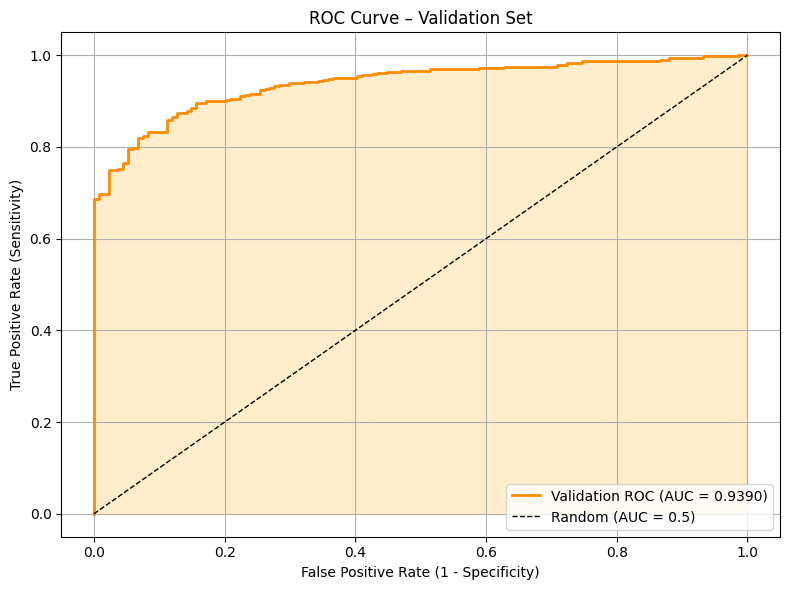

In [11]:

# VALIDATION ROC CURVE (BEST MODEL)

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import torch
import numpy as np

# Load best model (if not already loaded)
model.load_state_dict(torch.load('/kaggle/working/best_model.pth'))
model.eval()

# Get validation predictions
val_preds = []
val_labels = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy()
        if probs.ndim == 0:
            probs = [probs]
        val_preds.extend(probs)
        val_labels.extend(labels.numpy())

val_preds = np.array(val_preds)
val_labels = np.array(val_labels)

#Compute ROC and AUC
fpr, tpr, thresholds = roc_curve(val_labels, val_preds)
auc_val = roc_auc_score(val_labels, val_preds)

print(f"Validation AUC: {auc_val:.4f}")

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, color='darkorange', label=f'Validation ROC (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.2, color='orange')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve – Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('/kaggle/working/validation_roc.png', dpi=150)
plt.show()

ROC CURVES – TRAINING vs VALIDATION

Training AUC:   0.9793
 Validation AUC: 0.9390
   (Overfitting gap = 0.0403)


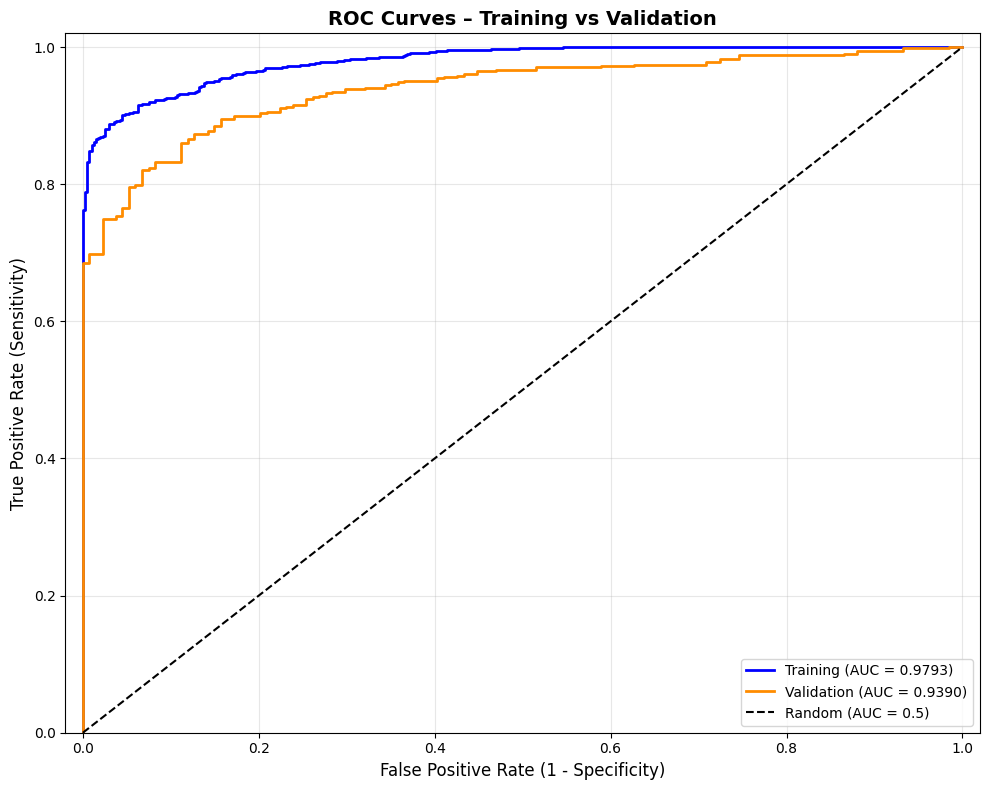


 ROC curves saved: /kaggle/working/roc_curves_train_val.png


In [12]:

# ROC CURVES FOR TRAINING AND VALIDATION SETS 

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import torch

print("=" * 60)
print("ROC CURVES – TRAINING vs VALIDATION")
print("=" * 60)

model.eval()
train_preds = []
train_labels = []
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        outputs = model(images).squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy()
        if probs.ndim == 0:
            probs = [probs]
        train_preds.extend(probs)
        train_labels.extend(labels.numpy())

train_preds = np.array(train_preds)
train_labels = np.array(train_labels)
train_auc = roc_auc_score(train_labels, train_preds)

val_preds = []
val_labels = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy()
        if probs.ndim == 0:
            probs = [probs]
        val_preds.extend(probs)
        val_labels.extend(labels.numpy())

val_preds = np.array(val_preds)
val_labels = np.array(val_labels)
val_auc = roc_auc_score(val_labels, val_preds)

print(f"\nTraining AUC:   {train_auc:.4f}")
print(f" Validation AUC: {val_auc:.4f}")
print(f"   (Overfitting gap = {train_auc - val_auc:.4f})")


fpr_train, tpr_train, thresh_train = roc_curve(train_labels, train_preds)
fpr_val,   tpr_val,   thresh_val   = roc_curve(val_labels, val_preds)

# Align lengths (safety)
min_len = min(len(fpr_train), len(tpr_train), len(thresh_train))
fpr_train = fpr_train[:min_len]
tpr_train = tpr_train[:min_len]
thresh_train = thresh_train[:min_len]

min_len = min(len(fpr_val), len(tpr_val), len(thresh_val))
fpr_val = fpr_val[:min_len]
tpr_val = tpr_val[:min_len]
thresh_val = thresh_val[:min_len]


plt.figure(figsize=(10, 8))

# Training ROC
plt.plot(fpr_train, tpr_train, lw=2, color='blue', label=f'Training (AUC = {train_auc:.4f})')
# Validation ROC
plt.plot(fpr_val, tpr_val, lw=2, color='darkorange', label=f'Validation (AUC = {val_auc:.4f})')
# Diagonal
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.5)')

plt.xlim(-0.02, 1.02)
plt.ylim(0.0, 1.02)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves – Training vs Validation', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/roc_curves_train_val.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n ROC curves saved: /kaggle/working/roc_curves_train_val.png")

## Confusion Matrix & Metrics

Loaded best model (AUC 0.9412)
Validation AUC: 0.9390
Optimal threshold (top‑left): 0.4824

Confusion Matrix:
True Negatives (Normal correct):   117
False Positives (Normal wrong):    17
False Negatives (Abnormal wrong):  64
True Positives (Abnormal correct): 442

Accuracy: 0.8734 (87.34%)

Classification Report:
              precision    recall  f1-score   support

      Normal       0.65      0.87      0.74       134
    Abnormal       0.96      0.87      0.92       506

    accuracy                           0.87       640
   macro avg       0.80      0.87      0.83       640
weighted avg       0.90      0.87      0.88       640



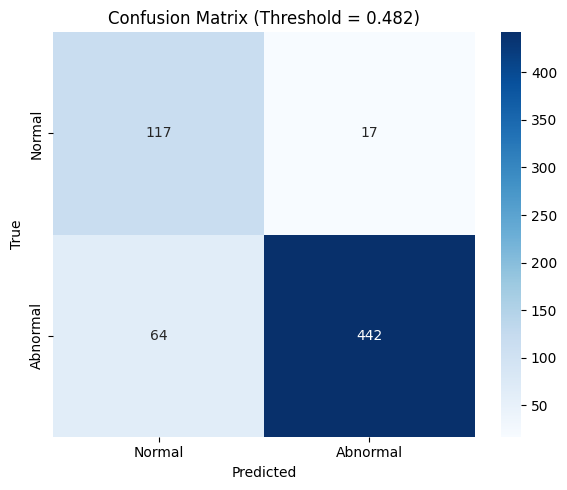


Classification Report:
              precision    recall  f1-score   support

      Normal       0.65      0.87      0.74       134
    Abnormal       0.96      0.87      0.92       506

    accuracy                           0.87       640
   macro avg       0.80      0.87      0.83       640
weighted avg       0.90      0.87      0.88       640


Summary metrics:
   Accuracy:    0.8734
   Precision:   0.9630
   Recall:      0.8735
   Specificity: 0.8731
   F1-score:    0.9161


In [13]:

#CONFUSION MATRIX AND CLASSIFICATION METRICS

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import numpy as np
import torch

# 1. Load best model
model.load_state_dict(torch.load('/kaggle/working/best_model.pth'))
model.eval()
print("Loaded best model (AUC 0.9412)")

# 2. Get validation predictions
val_preds = []
val_labels = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy()
        if probs.ndim == 0:
            probs = [probs]
        val_preds.extend(probs)
        val_labels.extend(labels.numpy())

val_preds = np.array(val_preds)
val_labels = np.array(val_labels)

# 3. Compute ROC and optimal threshold (top‑left corner)
fpr, tpr, thresholds = roc_curve(val_labels, val_preds)
dist = np.sqrt(fpr**2 + (1 - tpr)**2)
optimal_idx = np.argmin(dist)
best_thresh = thresholds[optimal_idx]
auc_val = roc_auc_score(val_labels, val_preds)

print(f"Validation AUC: {auc_val:.4f}")
print(f"Optimal threshold (top‑left): {best_thresh:.4f}")

# 4. Confusion matrix using that threshold
pred_binary = (val_preds >= best_thresh).astype(int)
cm = confusion_matrix(val_labels, pred_binary)

print("\nConfusion Matrix:")
print(f"True Negatives (Normal correct):   {cm[0,0]}")
print(f"False Positives (Normal wrong):    {cm[0,1]}")
print(f"False Negatives (Abnormal wrong):  {cm[1,0]}")
print(f"True Positives (Abnormal correct): {cm[1,1]}")

accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Optional: classification report
print("\nClassification Report:")
print(classification_report(val_labels, pred_binary, target_names=['Normal', 'Abnormal']))

pred_binary = (val_preds >= best_thresh).astype(int)
cm = confusion_matrix(val_labels, pred_binary)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Abnormal'], 
            yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (Threshold = {best_thresh:.3f})')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(val_labels, pred_binary, target_names=['Normal', 'Abnormal']))

tn, fp, fn, tp = cm.ravel()
accuracy = (tp+tn)/(tp+tn+fp+fn)
precision = tp/(tp+fp) if (tp+fp)>0 else 0
recall = tp/(tp+fn) if (tp+fn)>0 else 0
specificity = tn/(tn+fp) if (tn+fp)>0 else 0
f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0

print(f"\nSummary metrics:")
print(f"   Accuracy:    {accuracy:.4f}")
print(f"   Precision:   {precision:.4f}")
print(f"   Recall:      {recall:.4f}")
print(f"   Specificity: {specificity:.4f}")
print(f"   F1-score:    {f1:.4f}")

## Confidence Distribution

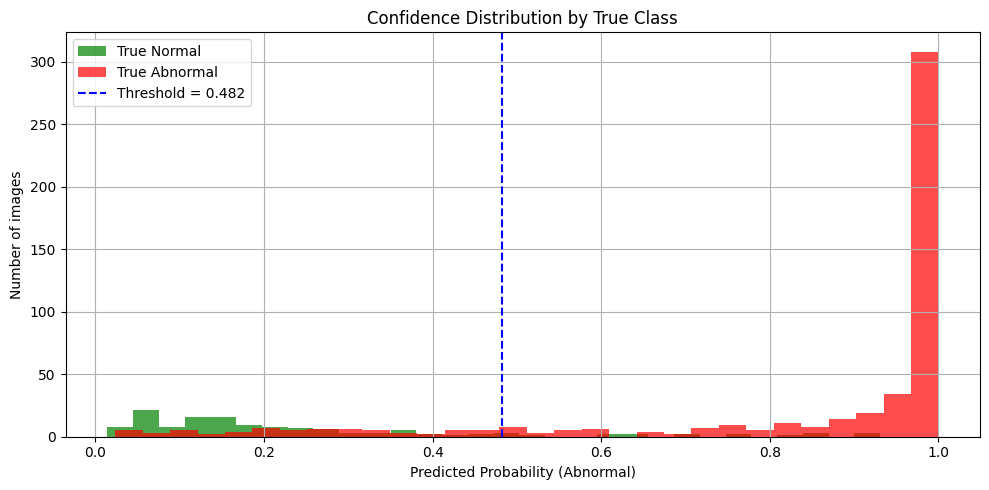

Mean confidence for NORMAL images:   0.2436
Mean confidence for ABNORMAL images: 0.8531


In [14]:

# MODEL CONFIDENCE DISTRIBUTION

normal_conf = val_preds[val_labels == 0]
abnormal_conf = val_preds[val_labels == 1]

plt.figure(figsize=(10,5))
plt.hist(normal_conf, bins=30, alpha=0.7, label='True Normal', color='green')
plt.hist(abnormal_conf, bins=30, alpha=0.7, label='True Abnormal', color='red')
plt.axvline(x=best_thresh, color='blue', linestyle='--', label=f'Threshold = {best_thresh:.3f}')
plt.xlabel('Predicted Probability (Abnormal)')
plt.ylabel('Number of images')
plt.title('Confidence Distribution by True Class')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/kaggle/working/confidence_dist.png', dpi=150)
plt.show()

print(f"Mean confidence for NORMAL images:   {np.mean(normal_conf):.4f}")
print(f"Mean confidence for ABNORMAL images: {np.mean(abnormal_conf):.4f}")

## Generate Test Predictions (Submission CSV)

In [15]:

#CREATE SUBMISSION CSV (SUB-CHA #1)
#Predict on test set
test_ids = test_dataset.image_ids
test_probs = []
with torch.no_grad():
    for images, _ in tqdm(test_loader, desc="Test inference"):
        images = images.to(device)
        outputs = model(images).squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy()
        if len(probs.shape) == 0:
            probs = [probs]
        test_probs.extend(probs)
#Load disease column names from training CSV
train_df = pd.read_csv(TRAIN_CSV)
disease_columns = train_df.columns[1:].tolist()
submission = pd.DataFrame({
    'ImageID': test_ids,
    'Probability': test_probs
})
#Fill all disease columns with 0 (we only do sub-challenge 1)
for col in disease_columns:
    submission[col] = 0.0
#Save
submission_path = '/kaggle/working/bikky_results.csv'
submission.to_csv(submission_path, index=False)

print(f"\nSubmission saved: {submission_path}")
print(f"   Shape: {submission.shape[0]} rows × {submission.shape[1]} cols")
print(f"   Columns: {list(submission.columns[:5])} ...")
print("\nPrediction stats:")
print(f"   Min: {submission['Probability'].min():.4f}")
print(f"   Max: {submission['Probability'].max():.4f}")
print(f"   Mean: {submission['Probability'].mean():.4f}")
print("\nFirst 5 rows:")
print(submission.head())

Test inference:   0%|          | 0/20 [00:00<?, ?it/s]


Submission saved: /kaggle/working/bikky_results.csv
   Shape: 640 rows × 31 cols
   Columns: ['ImageID', 'Probability', 'Disease_Risk', 'DR', 'ARMD'] ...

Prediction stats:
   Min: 0.0130
   Max: 0.9999
   Mean: 0.7076

First 5 rows:
   ImageID  Probability  Disease_Risk   DR  ARMD   MH   DN  MYA  BRVO  TSLN  \
0        1     0.994266           0.0  0.0   0.0  0.0  0.0  0.0   0.0   0.0   
1        2     0.997296           0.0  0.0   0.0  0.0  0.0  0.0   0.0   0.0   
2        3     0.994251           0.0  0.0   0.0  0.0  0.0  0.0   0.0   0.0   
3        4     0.959805           0.0  0.0   0.0  0.0  0.0  0.0   0.0   0.0   
4        5     0.163261           0.0  0.0   0.0  0.0  0.0  0.0   0.0   0.0   

   ...  AION   PT   RT   RS  CRS  EDN  RPEC  MHL   RP  OTHER  
0  ...   0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0    0.0  
1  ...   0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0    0.0  
2  ...   0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0    0.0  
3  ...   0.0  0.0  0.0  0.0  0.0  0.0 

## Download Outputs (Kaggle → local)

In [16]:

#DOWNLOAD RESULTS (Optional in Kaggle)

print("=" * 60)
print("FILES SAVED IN /kaggle/working/")
print("=" * 60)

for f in os.listdir('/kaggle/working'):
    if f.endswith('.pth') or f.endswith('.png') or f.endswith('.csv'):
        size_kb = os.path.getsize(f'/kaggle/working/{f}') / 1024
        print(f"   📄 {f} ({size_kb:.1f} KB)")

print("\nAll results are ready. Go to the 'Output' tab in Kaggle")
print("   and download 'bikky_results.csv' for submission.")

FILES SAVED IN /kaggle/working/
   📄 best_model.pth (15952.1 KB)
   📄 validation_roc.png (68.8 KB)
   📄 confusion_matrix.png (35.7 KB)
   📄 bikky_results.csv (81.6 KB)
   📄 training_curves.png (105.1 KB)
   📄 confidence_dist.png (47.7 KB)
   📄 roc_curves_train_val.png (91.3 KB)
   📄 roc_curve_training.png (89.4 KB)

All results are ready. Go to the 'Output' tab in Kaggle
   and download 'bikky_results.csv' for submission.


## Data Visualization (Pie Charts, Disease Lists, Co‑occurrence, Sample Images)

RFMiD DATASET VISUALIZATION (KAGGLE)

 DATASET OVERVIEW
----------------------------------------
Training set: 1920 images
Validation set: 640 images
Test set: 640 images
Total: 3200 images

Column filtering:
   Total columns: 30
   Excluded (non‑disease): 5
   Real disease columns: 28


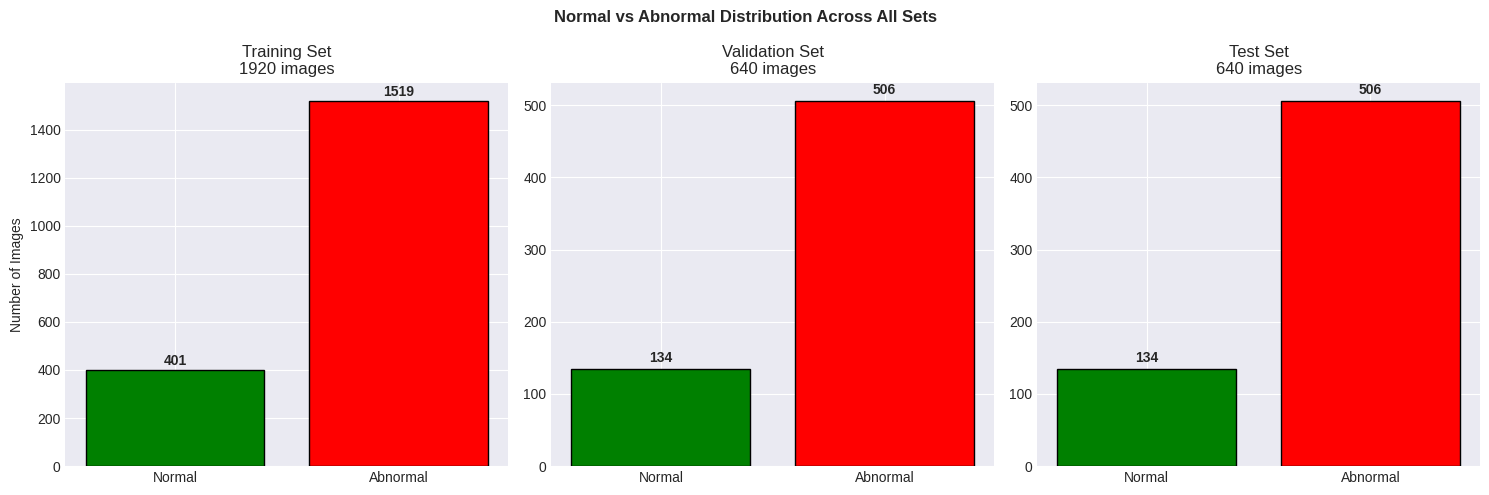


Distribution percentages:
   Training:   Normal 20.9% | Abnormal 79.1%
   Validation: Normal 20.9% | Abnormal 79.1%
   Test:       Normal 20.9% | Abnormal 79.1%


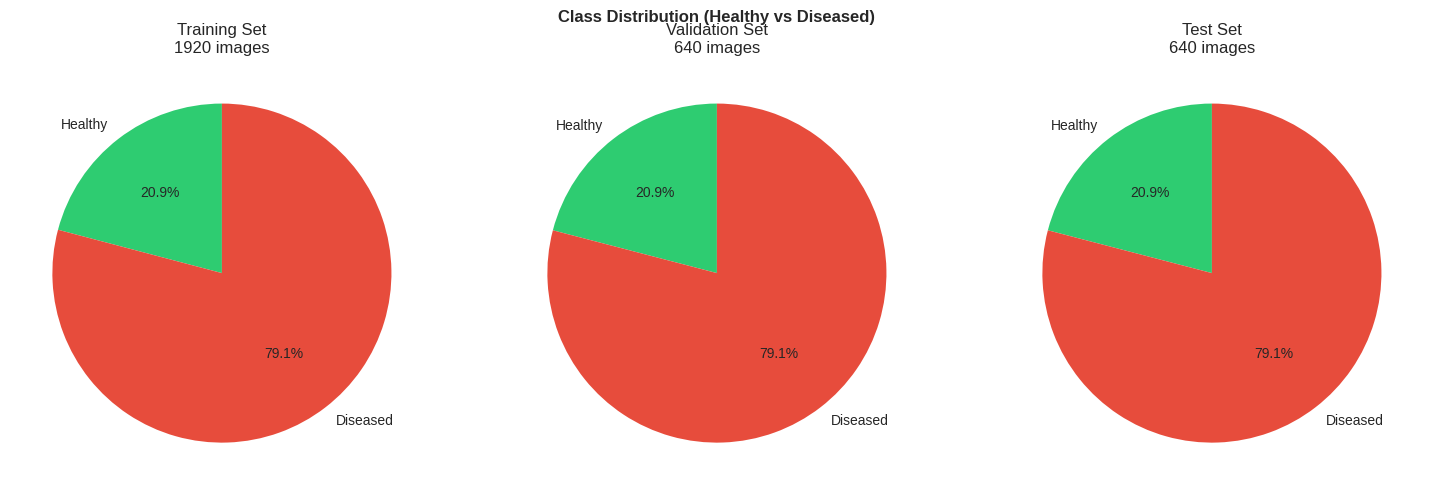

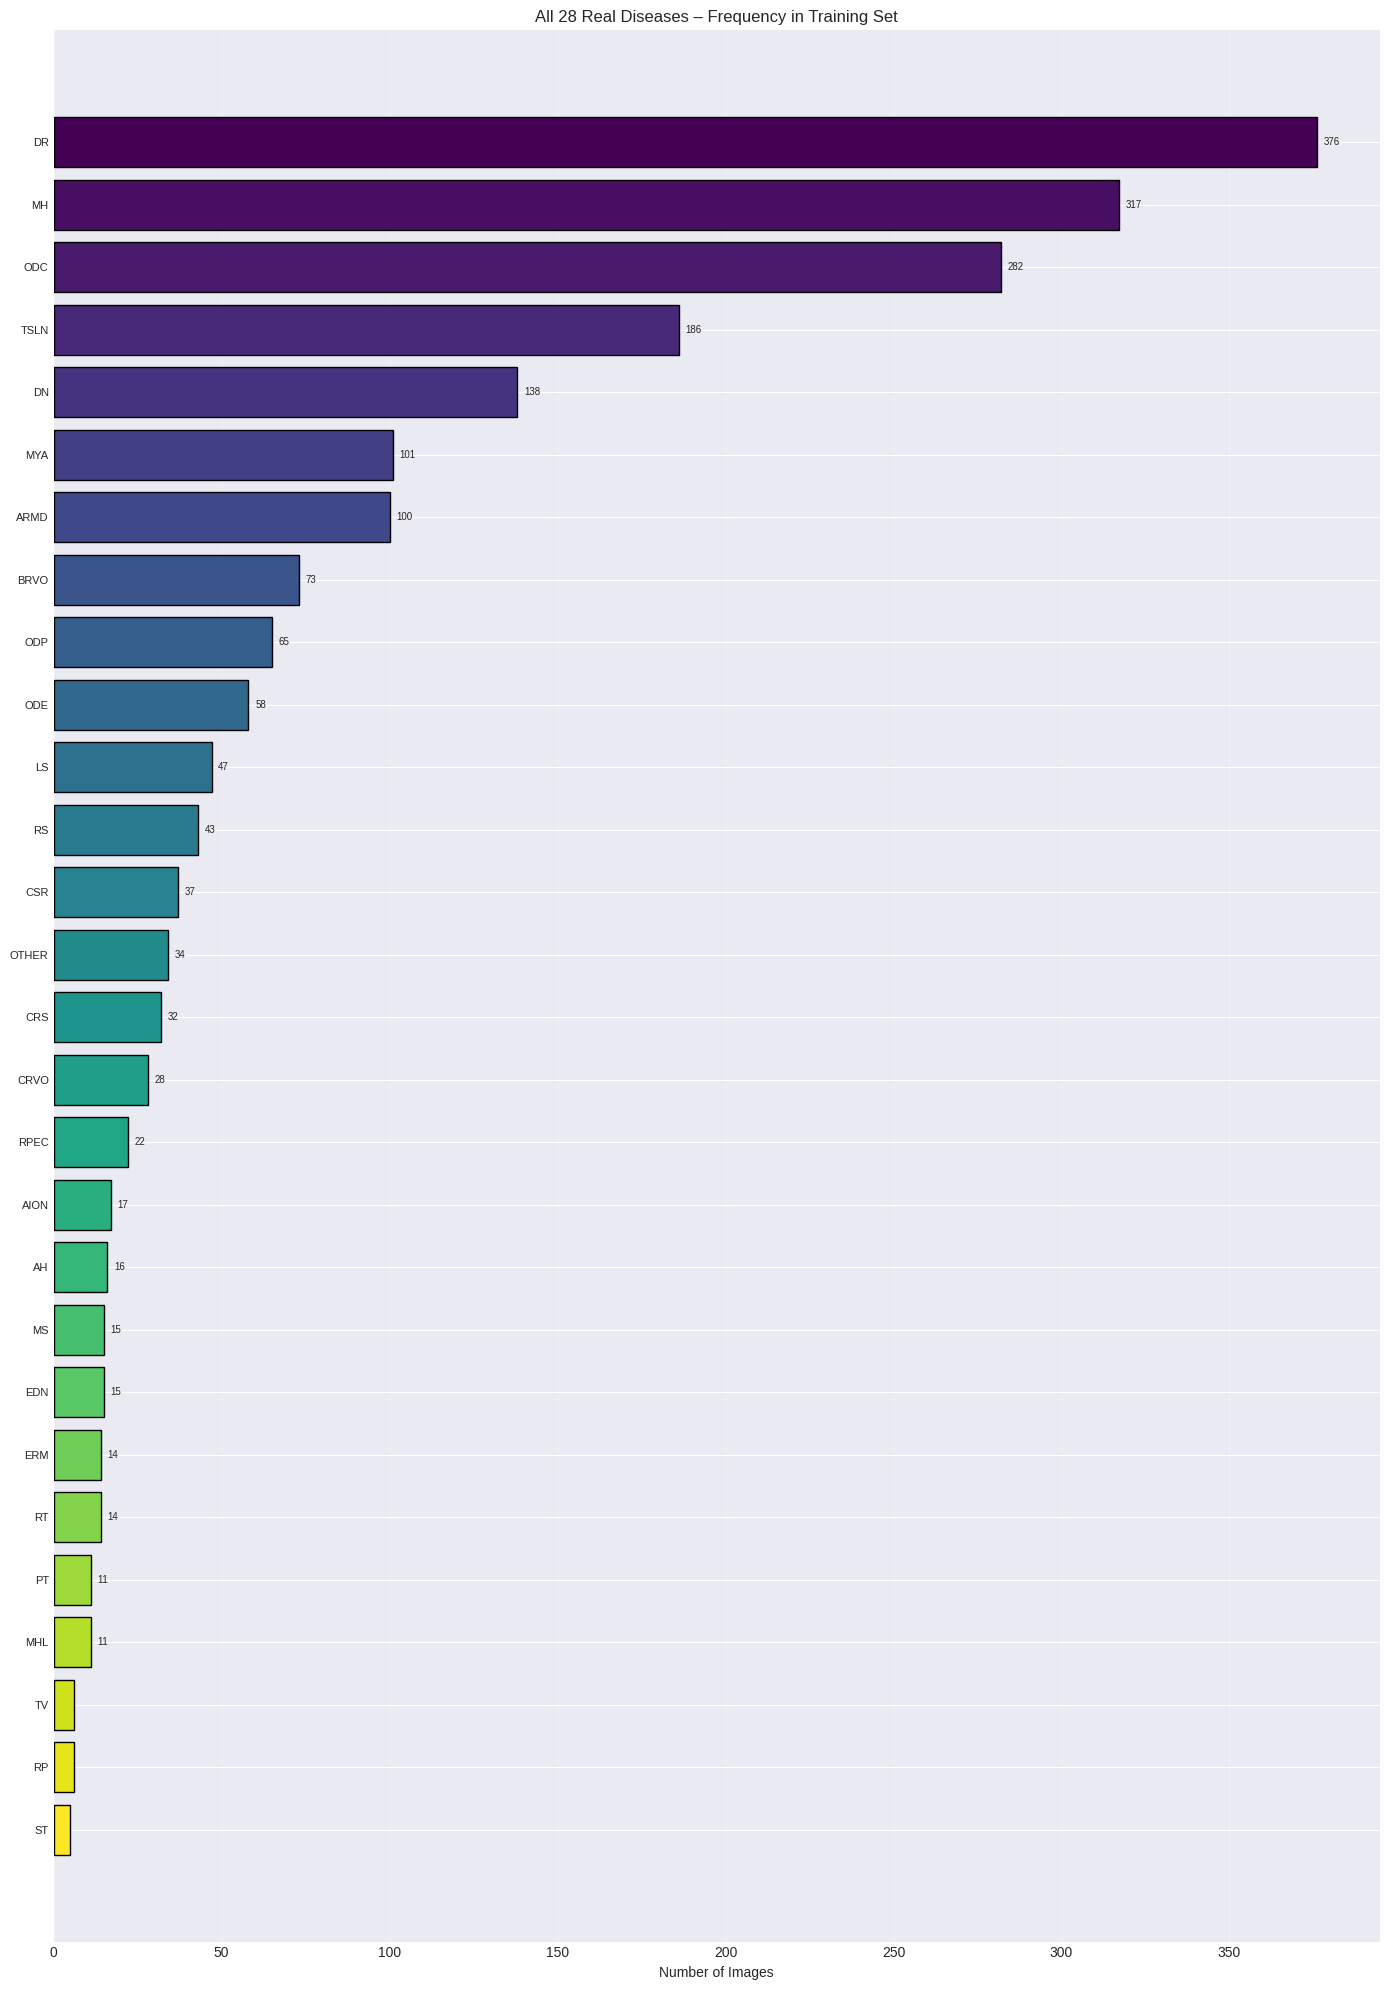


COMPLETE REAL DISEASE LIST (sorted by frequency):
  1. DR                                             376 images (19.6%)
  2. MH                                             317 images (16.5%)
  3. ODC                                            282 images (14.7%)
  4. TSLN                                           186 images (9.7%)
  5. DN                                             138 images (7.2%)
  6. MYA                                            101 images (5.3%)
  7. ARMD                                           100 images (5.2%)
  8. BRVO                                            73 images (3.8%)
  9. ODP                                             65 images (3.4%)
 10. ODE                                             58 images (3.0%)
 11. LS                                              47 images (2.4%)
 12. RS                                              43 images (2.2%)
 13. CSR                                             37 images (1.9%)
 14. OTHER                          

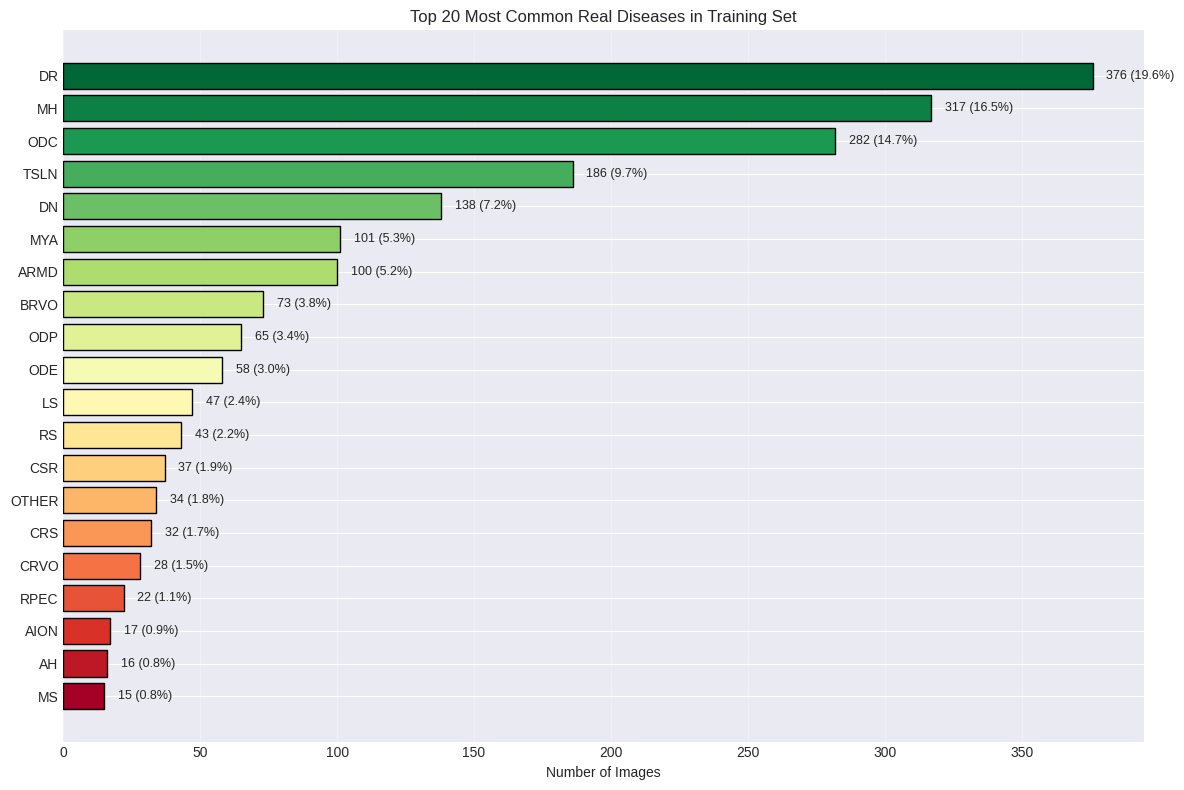

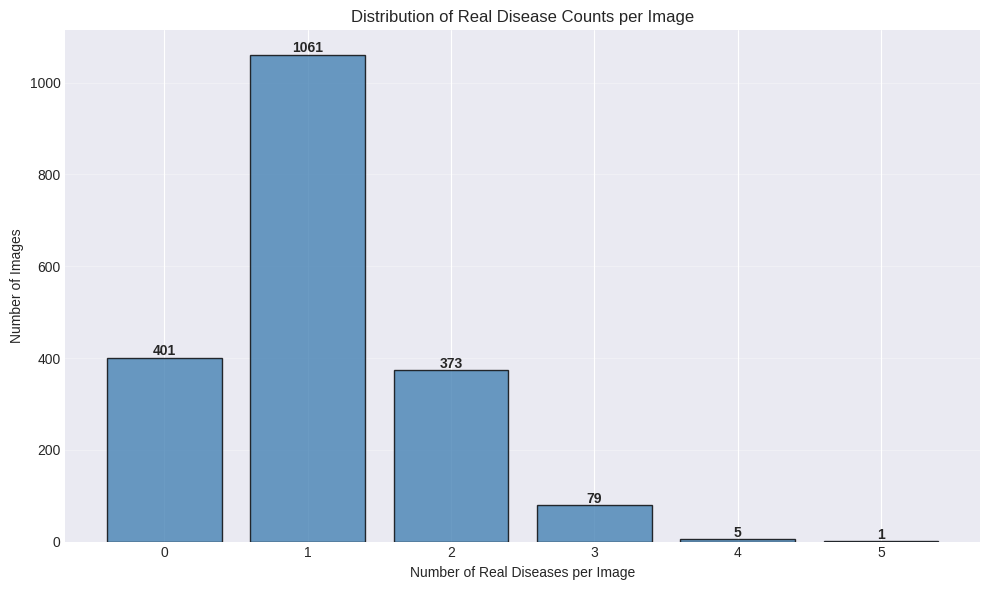


Statistics (Real Diseases Only):
Images with 0 real diseases (HEALTHY): 401
Images with 1 real disease:           1061
Images with 2 real diseases:          373
Images with 3+ real diseases:         85
   Average real diseases per image:      1.08
   Maximum real diseases in one image:   5


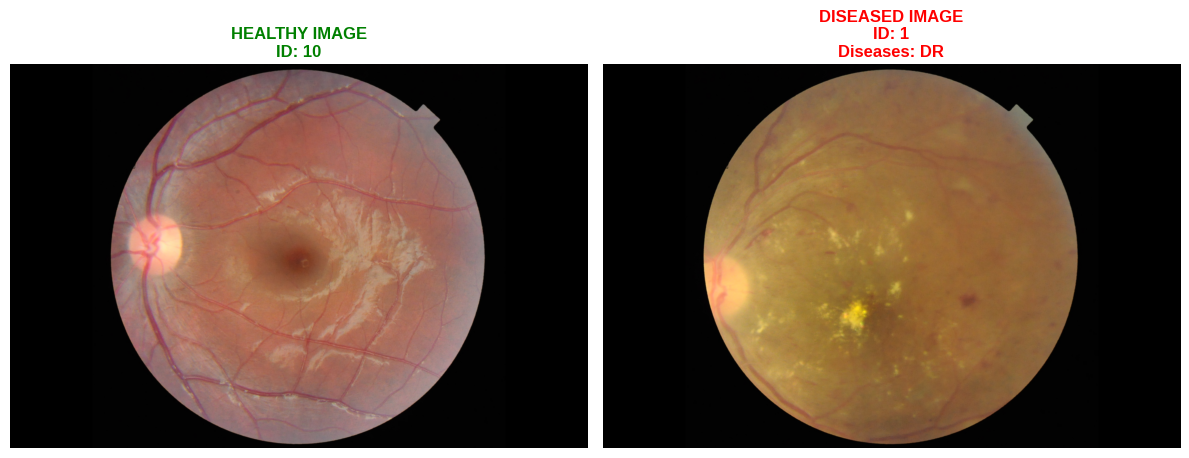

Sample healthy image ID: 10
Sample diseased image ID: 1

SUMMARY TABLE
       Set  Total Images  Healthy  Diseased Disease %
  Training          1920      401      1519     79.1%
Validation           640      134       506     79.1%
      Test           640      134       506     79.1%
     TOTAL          3200      669      2531     79.1%

All visualizations saved to /kaggle/working/
   Files: normal_vs_abnormal.png, pie_charts.png, all_diseases.png, top_20_diseases.png, diseases_per_image.png, sample_images.png


In [17]:

#DATASET VISUALIZATION (PIE CHARTS, DISEASE LISTS, CO-OCCURRENCE)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from PIL import Image

#Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 60)
print("RFMiD DATASET VISUALIZATION (KAGGLE)")
print("=" * 60)

#Use the same base path as in training
BASE = "/kaggle/input/datasets/bikramchapagain/rmidd-datasets"

#Load data – note the nested folder structure we discovered earlier
train_df = pd.read_csv(os.path.join(BASE, "Training_Set", "Training_Set", "RFMiD_Training_Labels.csv"))
val_df   = pd.read_csv(os.path.join(BASE, "Evaluation_Set", "Evaluation_Set", "RFMiD_Validation_Labels.csv"))
test_df  = pd.read_csv(os.path.join(BASE, "Test_Set", "Test_Set", "RFMiD_Testing_Labels.csv"))

print("\n DATASET OVERVIEW")
print("-" * 40)
print(f"Training set: {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")
print(f"Test set: {len(test_df)} images")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)} images")


#EXCLUDE NON‑DISEASE COLUMNS (ID, Disease_Risk, etc.)

all_columns = train_df.columns.tolist()
EXCLUDE_COLUMNS = ['ID', 'Disease_Risk', 'Risk_Factor', 'Unclear', 'Uncertain']
real_disease_cols = [col for col in all_columns if col not in EXCLUDE_COLUMNS]

print(f"\nColumn filtering:")
print(f"   Total columns: {len(all_columns)}")
print(f"   Excluded (non‑disease): {len(EXCLUDE_COLUMNS)}")
print(f"   Real disease columns: {len(real_disease_cols)}")


#BINARY LABELS (Normal / Abnormal) USING ONLY REAL DISEASES

train_binary = (train_df[real_disease_cols].sum(axis=1) > 0).astype(int)
val_binary   = (val_df[real_disease_cols].sum(axis=1) > 0).astype(int)
test_binary  = (test_df[real_disease_cols].sum(axis=1) > 0).astype(int)

train_normal = (train_binary == 0).sum()
train_abnormal = (train_binary == 1).sum()
val_normal = (val_binary == 0).sum()
val_abnormal = (val_binary == 1).sum()
test_normal = (test_binary == 0).sum()
test_abnormal = (test_binary == 1).sum()


#BAR PLOT: Normal vs Abnormal (already shown earlier but we repeat for completeness)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#Training
axes[0].bar(['Normal', 'Abnormal'], [train_normal, train_abnormal], color=['green','red'], edgecolor='black')
axes[0].set_title(f'Training Set\n{len(train_df)} images')
axes[0].set_ylabel('Number of Images')
for i, v in enumerate([train_normal, train_abnormal]):
    axes[0].text(i, v+20, str(v), ha='center', fontweight='bold')

#Validation
axes[1].bar(['Normal', 'Abnormal'], [val_normal, val_abnormal], color=['green','red'], edgecolor='black')
axes[1].set_title(f'Validation Set\n{len(val_df)} images')
for i, v in enumerate([val_normal, val_abnormal]):
    axes[1].text(i, v+10, str(v), ha='center', fontweight='bold')

#Test
axes[2].bar(['Normal', 'Abnormal'], [test_normal, test_abnormal], color=['green','red'], edgecolor='black')
axes[2].set_title(f'Test Set\n{len(test_df)} images')
for i, v in enumerate([test_normal, test_abnormal]):
    axes[2].text(i, v+10, str(v), ha='center', fontweight='bold')

plt.suptitle('Normal vs Abnormal Distribution Across All Sets', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/normal_vs_abnormal.png', dpi=150)
plt.show()

print(f"\nDistribution percentages:")
print(f"   Training:   Normal {train_normal/len(train_df)*100:.1f}% | Abnormal {train_abnormal/len(train_df)*100:.1f}%")
print(f"   Validation: Normal {val_normal/len(val_df)*100:.1f}% | Abnormal {val_abnormal/len(val_df)*100:.1f}%")
print(f"   Test:       Normal {test_normal/len(test_df)*100:.1f}% | Abnormal {test_abnormal/len(test_df)*100:.1f}%")

#PIE CHARTS
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_pie = ['#2ecc71', '#e74c3c']

axes[0].pie([train_normal, train_abnormal], labels=['Healthy','Diseased'], autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[0].set_title(f'Training Set\n{len(train_df)} images')
axes[1].pie([val_normal, val_abnormal], labels=['Healthy','Diseased'], autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[1].set_title(f'Validation Set\n{len(val_df)} images')
axes[2].pie([test_normal, test_abnormal], labels=['Healthy','Diseased'], autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[2].set_title(f'Test Set\n{len(test_df)} images')

plt.suptitle('Class Distribution (Healthy vs Diseased)', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/pie_charts.png', dpi=150)
plt.show()


# DISEASE FREQUENCY (ALL REAL DISEASES)
disease_counts = train_df[real_disease_cols].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, max(20, len(disease_counts)*0.3)))
colors = plt.cm.viridis(np.linspace(0,1,len(disease_counts)))
bars = ax.barh(range(len(disease_counts)), disease_counts.values, color=colors, edgecolor='black')
ax.set_yticks(range(len(disease_counts)))
ax.set_yticklabels([name.replace('_',' ') for name in disease_counts.index], fontsize=8)
ax.set_xlabel('Number of Images')
ax.set_title(f'All {len(disease_counts)} Real Diseases – Frequency in Training Set')
ax.invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, disease_counts.values)):
    if i < 20 or val > 10:
        ax.text(val+2, bar.get_y()+bar.get_height()/2, f'{int(val)}', va='center', fontsize=7)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/all_diseases.png', dpi=150)
plt.show()

#Print full list
print("\nCOMPLETE REAL DISEASE LIST (sorted by frequency):")
for i, (disease, count) in enumerate(disease_counts.items(), 1):
    print(f"{i:3d}. {disease.replace('_',' '):45s} {int(count):4d} images ({count/len(train_df)*100:.1f}%)")

#TOP 20 DISEASES (clearer view)
top_20 = disease_counts.head(20)
fig, ax = plt.subplots(figsize=(12,8))
colors = plt.cm.RdYlGn_r(np.linspace(0,1,len(top_20)))
bars = ax.barh(range(len(top_20)), top_20.values, color=colors, edgecolor='black')
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels([name.replace('_',' ') for name in top_20.index], fontsize=10)
ax.set_xlabel('Number of Images')
ax.set_title('Top 20 Most Common Real Diseases in Training Set')
ax.invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, top_20.values)):
    ax.text(val+5, bar.get_y()+bar.get_height()/2, f'{int(val)} ({val/len(train_df)*100:.1f}%)', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/top_20_diseases.png', dpi=150)
plt.show()
#DISEASE CO‑OCCURRENCE (real diseases per image)
real_disease_count = train_df[real_disease_cols].sum(axis=1)
disease_dist = real_disease_count.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(disease_dist.index, disease_dist.values, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('Number of Real Diseases per Image')
ax.set_ylabel('Number of Images')
ax.set_title('Distribution of Real Disease Counts per Image')
for bar, val in zip(bars, disease_dist.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(val), ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/diseases_per_image.png', dpi=150)
plt.show()

print(f"\nStatistics (Real Diseases Only):")
print(f"Images with 0 real diseases (HEALTHY): {disease_dist.get(0, 0)}")
print(f"Images with 1 real disease:           {disease_dist.get(1, 0)}")
print(f"Images with 2 real diseases:          {disease_dist.get(2, 0)}")
print(f"Images with 3+ real diseases:         {disease_dist[disease_dist.index >= 3].sum()}")
print(f"   Average real diseases per image:      {real_disease_count.mean():.2f}")
print(f"   Maximum real diseases in one image:   {real_disease_count.max()}")

#SAMPLE IMAGES (healthy vs diseased)
#Use first healthy and first diseased from training set
healthy_id = train_df[train_binary == 0].iloc[0, 0]
diseased_id = train_df[train_binary == 1].iloc[0, 0]

#Build paths (use the correct nested folder)
healthy_path = os.path.join(BASE, "Training_Set", "Training_Set", "Training", f"{healthy_id}.png")
if not os.path.exists(healthy_path):
    healthy_path = healthy_path.replace('.png', '.jpg')

diseased_path = os.path.join(BASE, "Training_Set", "Training_Set", "Training", f"{diseased_id}.png")
if not os.path.exists(diseased_path):
    diseased_path = diseased_path.replace('.png', '.jpg')

fig, axes = plt.subplots(1,2, figsize=(12,5))

if os.path.exists(healthy_path):
    img = Image.open(healthy_path)
    axes[0].imshow(img)
    axes[0].set_title(f'HEALTHY IMAGE\nID: {healthy_id}', color='green', fontweight='bold')
else:
    axes[0].text(0.5,0.5,'Image not found', ha='center', va='center')

if os.path.exists(diseased_path):
    img = Image.open(diseased_path)
    axes[1].imshow(img)
    # Get real diseases for this image
    row = train_df[train_df.iloc[:,0] == diseased_id]
    disease_list = [col.replace('_',' ') for col in real_disease_cols if row[col].values[0]==1]
    title = f'DISEASED IMAGE\nID: {diseased_id}\n'
    if disease_list:
        title += f'Diseases: {", ".join(disease_list[:3])}'
        if len(disease_list)>3:
            title += f' +{len(disease_list)-3} more'
    axes[1].set_title(title, color='red', fontweight='bold')
else:
    axes[1].text(0.5,0.5,'Image not found', ha='center', va='center')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=150)
plt.show()

print(f"Sample healthy image ID: {healthy_id}")
print(f"Sample diseased image ID: {diseased_id}")

summary_data = {
    'Set': ['Training', 'Validation', 'Test', 'TOTAL'],
    'Total Images': [len(train_df), len(val_df), len(test_df), len(train_df)+len(val_df)+len(test_df)],
    'Healthy': [train_normal, val_normal, test_normal, train_normal+val_normal+test_normal],
    'Diseased': [train_abnormal, val_abnormal, test_abnormal, train_abnormal+val_abnormal+test_abnormal],
    'Disease %': [f"{train_abnormal/len(train_df)*100:.1f}%",
                  f"{val_abnormal/len(val_df)*100:.1f}%",
                  f"{test_abnormal/len(test_df)*100:.1f}%",
                  f"{(train_abnormal+val_abnormal+test_abnormal)/(len(train_df)+len(val_df)+len(test_df))*100:.1f}%"]
}
summary_df = pd.DataFrame(summary_data)
print("\nSUMMARY TABLE")
print(summary_df.to_string(index=False))

print("\nAll visualizations saved to /kaggle/working/")
print("   Files: normal_vs_abnormal.png, pie_charts.png, all_diseases.png, top_20_diseases.png, diseases_per_image.png, sample_images.png")


 Training Set Statistics (Real Diseases Only):
   Images with 0 diseases (HEALTHY): 401
   Images with 1 disease:           1061
   Images with 2 diseases:          373
   Images with 3+ diseases:         85
   Average diseases per image:      1.08
   Maximum diseases in one image:   5

 Validation Set Statistics (Real Diseases Only):
   Images with 0 diseases (HEALTHY): 134
   Images with 1 disease:           355
   Images with 2 diseases:          116
   Images with 3+ diseases:         35
   Average diseases per image:      1.08
   Maximum diseases in one image:   3

 Test Set Statistics (Real Diseases Only):
   Images with 0 diseases (HEALTHY): 134
   Images with 1 disease:           367
   Images with 2 diseases:          116
   Images with 3+ diseases:         23
   Average diseases per image:      1.05
   Maximum diseases in one image:   4


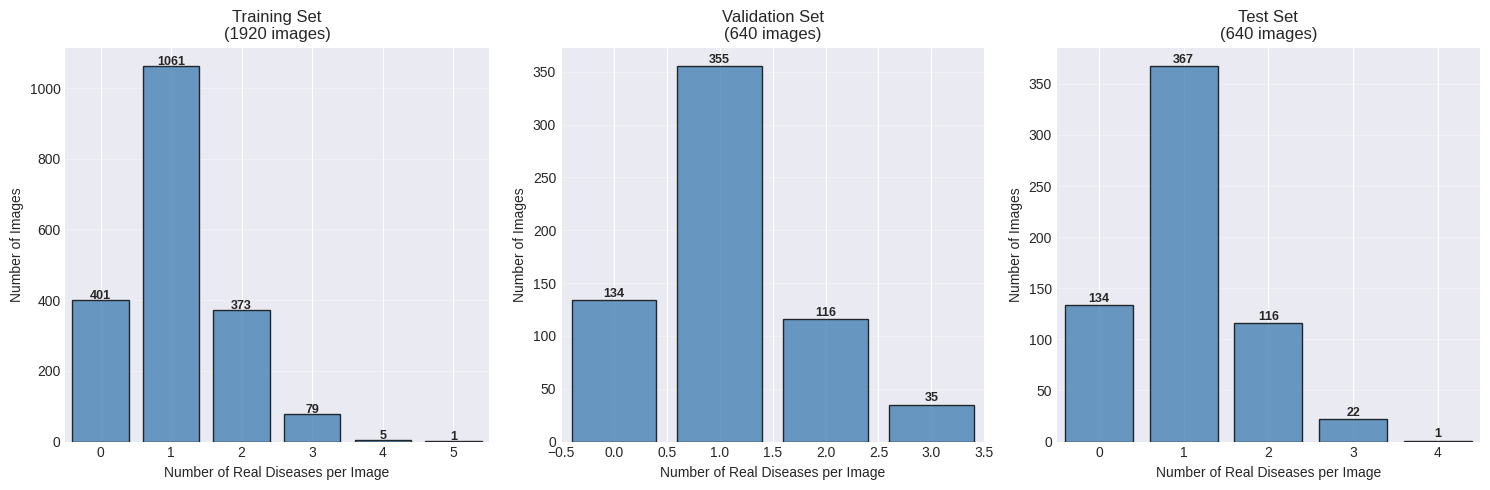


Disease co‑occurrence plots saved: /kaggle/working/diseases_per_image_all_sets.png


In [18]:

# DISEASE CO‑OCCURRENCE FOR ALL SETS


# Lists to store results
sets = {
    'Training': train_df,
    'Validation': val_df,
    'Test': test_df
}

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (set_name, df) in zip(axes, sets.items()):
    # Count real diseases per image
    real_count = df[real_disease_cols].sum(axis=1)
    dist = real_count.value_counts().sort_index()
    
    # Bar plot
    bars = ax.bar(dist.index, dist.values, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_xlabel('Number of Real Diseases per Image')
    ax.set_ylabel('Number of Images')
    ax.set_title(f'{set_name} Set\n({len(df)} images)')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, dist.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(val), ha='center', fontweight='bold', fontsize=9)
    
    # Optional: limit x-axis to max value present
    if len(dist) > 0:
        ax.set_xlim(-0.5, dist.index.max() + 0.5)
    
    # Print statistics for this set
    print(f"\n {set_name} Set Statistics (Real Diseases Only):")
    print(f"   Images with 0 diseases (HEALTHY): {dist.get(0, 0)}")
    print(f"   Images with 1 disease:           {dist.get(1, 0)}")
    print(f"   Images with 2 diseases:          {dist.get(2, 0)}")
    print(f"   Images with 3+ diseases:         {dist[dist.index >= 3].sum() if any(dist.index >= 3) else 0}")
    print(f"   Average diseases per image:      {real_count.mean():.2f}")
    print(f"   Maximum diseases in one image:   {real_count.max()}")

plt.tight_layout()
plt.savefig('/kaggle/working/diseases_per_image_all_sets.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDisease co‑occurrence plots saved: /kaggle/working/diseases_per_image_all_sets.png")

In [19]:
#EVALUATION METRICS
print(f"Validation AUC: {best_auc:.4f}")

Validation AUC: 0.9390


In [20]:

#CONFUSION MATRIX & ACCURACY (with automatic optimal threshold)
from sklearn.metrics import confusion_matrix, roc_curve
import numpy as np

#Compute optimal threshold (Youden's index)
fpr, tpr, thresholds = roc_curve(val_labels, val_preds)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold (Youden's index): {optimal_threshold:.4f}")

#Convert probabilities to binary using optimal threshold
val_preds_binary = (val_preds >= optimal_threshold).astype(int)

#Confusion matrix
cm = confusion_matrix(val_labels, val_preds_binary)

print("\n" + "=" * 60)
print("CONFUSION MATRIX (Validation Set)")
print("=" * 60)
print(f"True Negatives  (Normal correct):   {cm[0,0]}")
print(f"False Positives (Normal wrong):     {cm[0,1]}")
print(f"False Negatives (Abnormal wrong):   {cm[1,0]}")
print(f"True Positives  (Abnormal correct): {cm[1,1]}")

# Accuracy
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")   # <-- closing parenthesis added

Optimal threshold (Youden's index): 0.7118

CONFUSION MATRIX (Validation Set)
True Negatives  (Normal correct):   125
False Positives (Normal wrong):     9
False Negatives (Abnormal wrong):   91
True Positives  (Abnormal correct): 415

Accuracy: 0.8438 (84.38%)


TESTING MODEL ON SAMPLE IMAGES (KAGGLE)

Testing HEALTHY image (ID=10):


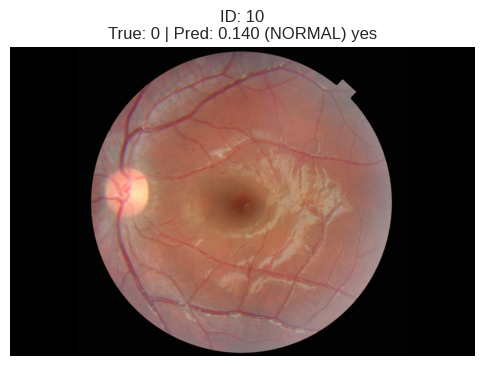


Testing DISEASED image (ID=1):


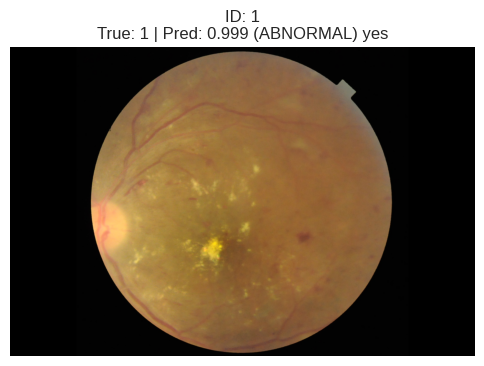

(0.9993933439254761, 'ABNORMAL')

In [21]:

#TEST MODEL ON SPECIFIC IMAGES (KAGGLE VERSION)


import matplotlib.pyplot as plt
from PIL import Image
import os

# Base path for Kaggle dataset
KAGGLE_BASE = "/kaggle/input/datasets/bikramchapagain/rmidd-datasets"

def test_image(image_id, true_label, dataset_type='Training'):
    """
    Test model on a specific image and show prediction.
    dataset_type: 'Training', 'Validation', or 'Test'
    """
    #Build path based on dataset_type
    if dataset_type == 'Training':
        img_path = os.path.join(KAGGLE_BASE, "Training_Set", "Training_Set", "Training", f"{image_id}.png")
    elif dataset_type == 'Validation':
        img_path = os.path.join(KAGGLE_BASE, "Evaluation_Set", "Evaluation_Set", "Validation", f"{image_id}.png")
    else:  #Test
        img_path = os.path.join(KAGGLE_BASE, "Test_Set", "Test_Set", "Test", f"{image_id}.png")
    
    #Fallback to .jpg if .png doesn't exist
    if not os.path.exists(img_path):
        img_path = img_path.replace('.png', '.jpg')
    
    #Preprocess
    from torchvision import transforms
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    #Load and transform image
    image = Image.open(img_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    #Predict
    model.eval()
    with torch.no_grad():
        output = model(input_tensor).squeeze()
        prob = torch.sigmoid(output).cpu().item()
    
    prediction = "ABNORMAL" if prob > 0.5 else "NORMAL"
    correct = "yes" if ((prediction == "ABNORMAL" and true_label == 1) or
                       (prediction == "NORMAL" and true_label == 0)) else "No"
    
    #Display
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"ID: {image_id}\nTrue: {true_label} | Pred: {prob:.3f} ({prediction}) {correct}")
    plt.show()
    
    return prob, prediction

print("TESTING MODEL ON SAMPLE IMAGES (KAGGLE)")


#Test healthy image (ID 10 – exists in Training set)
print("\nTesting HEALTHY image (ID=10):")
test_image(10, true_label=0, dataset_type='Training')

#Test diseased image (ID 1 – exists in Training set)
print("\nTesting DISEASED image (ID=1):")
test_image(1, true_label=1, dataset_type='Training')

## VALIDATE ON RANDOM BATCH OF VALIDATION SET

VALIDATING ON RANDOM SAMPLES


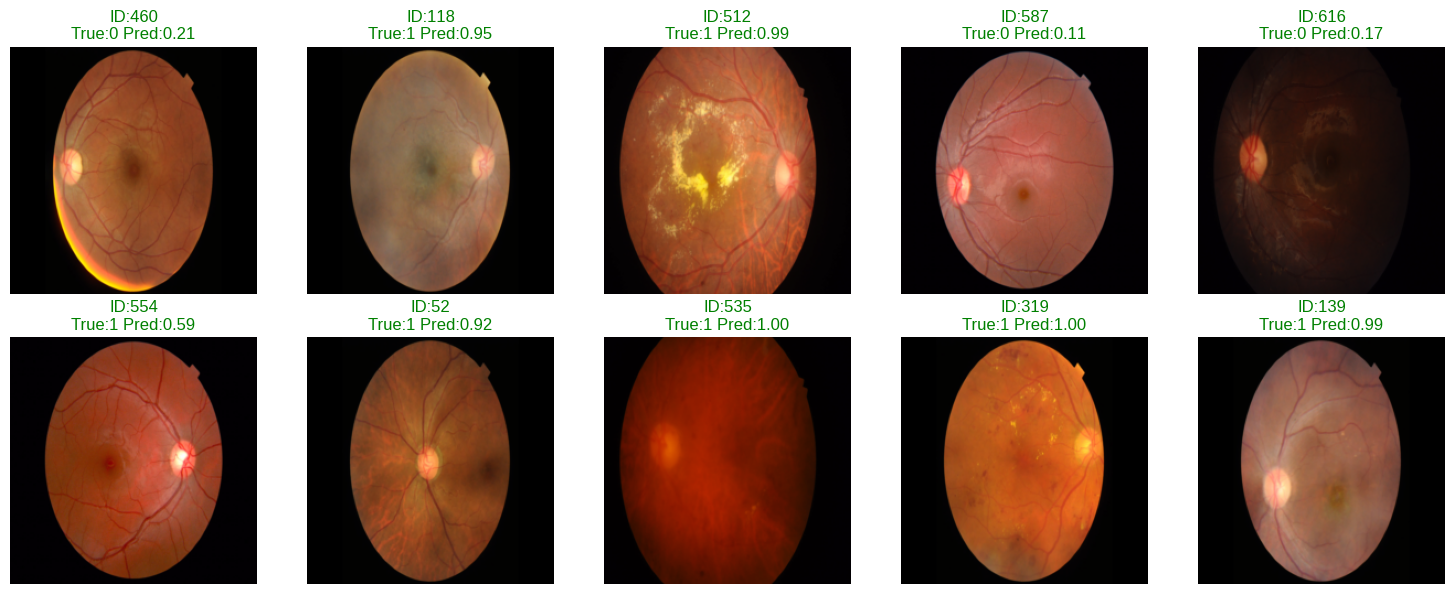


Accuracy on 10 random samples: 10/10 (100%)


In [22]:
#VALIDATE ON RANDOM BATCH OF VALIDATION SET
import random
print("VALIDATING ON RANDOM SAMPLES")
#Get random indices from validation set
num_samples = 10
indices = random.sample(range(len(val_dataset)), num_samples)
model.eval()
correct = 0
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for idx, sample_idx in enumerate(indices):
    # get image and true label
    image, true_label = val_dataset[sample_idx]
    image_id = val_dataset.image_ids[sample_idx]
    # predict
    with torch.no_grad():
        input_tensor = image.unsqueeze(0).to(device)
        output = model(input_tensor).squeeze()
        prob = torch.sigmoid(output).cpu().item()
    pred_label = 1 if prob > 0.5 else 0
    is_correct = (pred_label == true_label)
    correct += is_correct

    # show image (denormalize)
    img_display = image.cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    color = 'green' if is_correct else 'red'
    axes[idx].imshow(img_display)
    axes[idx].set_title(f"ID:{image_id}\nTrue:{int(true_label)} Pred:{prob:.2f}", color=color)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"\nAccuracy on {num_samples} random samples: {correct}/{num_samples} ({correct/num_samples*100:.0f}%)")